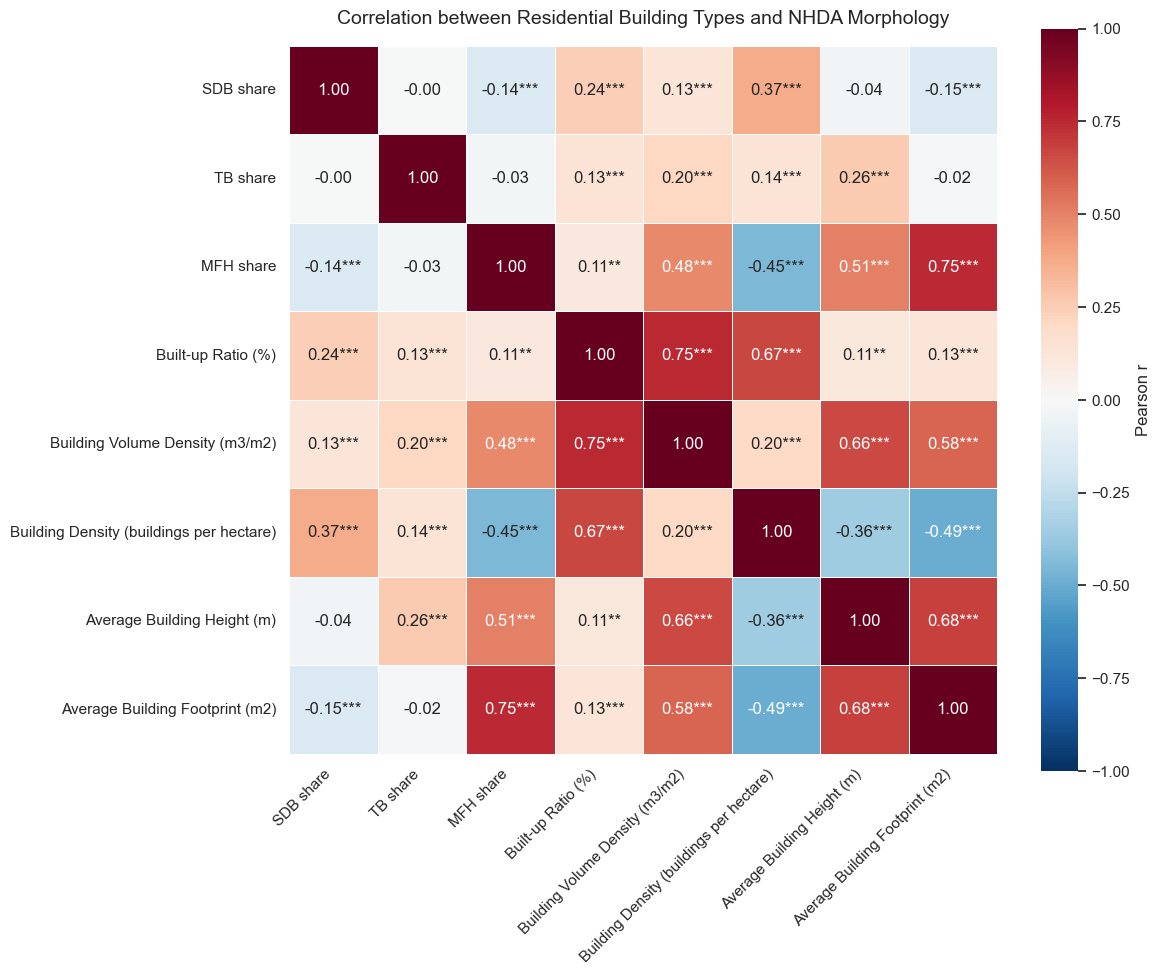

Saved figure: C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\nhda_morphology\corr_res_building_types_vs_nhda_morphology.jpg

Correlation matrix (Pearson r):


,SDB share,TB share,MFH share,Built-up Ratio (%),Building Volume Density (m3/m2),Building Density (buildings per hectare),Average Building Height (m),Average Building Footprint (m2)
SDB share,1.000,-0.000,-0.145,0.245,0.129,0.371,-0.036,-0.152
TB share,-0.000,1.000,-0.029,0.134,0.205,0.137,0.265,-0.020
MFH share,-0.145,-0.029,1.000,0.108,0.483,-0.450,0.507,0.747
Built-up Ratio (%),0.245,0.134,0.108,1.000,0.754,0.668,0.113,0.130
Building Volume Density (m3/m2),0.129,0.205,0.483,0.754,1.000,0.202,0.657,0.580
Building Density (buildings per hectare),0.371,0.137,-0.450,0.668,0.202,1.000,-0.356,-0.495
Average Building Height (m),-0.036,0.265,0.507,0.113,0.657,-0.356,1.000,0.684
Average Building Footprint (m2),-0.152,-0.020,0.747,0.130,0.580,-0.495,0.684,1.000



P-value matrix:


,SDB share,TB share,MFH share,Built-up Ratio (%),Building Volume Density (m3/m2),Building Density (buildings per hectare),Average Building Height (m),Average Building Footprint (m2)
SDB share,0.000000,0.989458,0.000025,0.000000,0.000173,0.000000,0.291339,0.000010
TB share,0.989458,0.000000,0.400910,0.000096,0.000000,0.000066,0.000000,0.562727
MFH share,0.000025,0.400910,0.000000,0.001711,0.000000,0.000000,0.000000,0.000000
Built-up Ratio (%),0.000000,0.000096,0.001711,0.000000,0.000000,0.000000,0.001047,0.000159
Building Volume Density (m3/m2),0.000173,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Building Density (buildings per hectare),0.000000,0.000066,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Average Building Height (m),0.291339,0.000000,0.000000,0.001047,0.000000,0.000000,0.000000,0.000000
Average Building Footprint (m2),0.000010,0.562727,0.000000,0.000159,0.000000,0.000000,0.000000,0.000000


In [5]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr

# -----------------------------------------------------------------------------
# Input
# -----------------------------------------------------------------------------
gpkg_file = r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Analysis_w_LoD2\Comparison_NHDA_RA\Comparison_LST_NDVI_DEGURB_CLC_BuildingStructure.gpkg"
EXPORT_PATH = Path(r"C:\Users\agz90fk\Documents\Masterarbeit\03_Daten\Output\Figures\nhda_morphology")
# -----------------------------------------------------------------------------
# Load NHDA data
# -----------------------------------------------------------------------------
gdf = gpd.read_file(gpkg_file)
if "type" in gdf.columns:
    gdf = gdf[gdf["type"] == "NHDA"].copy()

# -----------------------------------------------------------------------------
# Robust column resolver (supports naming variants / typos)
# -----------------------------------------------------------------------------
def pick_existing_column(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f"Keine passende Spalte gefunden fuer '{label}'. Geprueft: {candidates}")

column_candidates = {
    # Building type shares (SFH intentionally excluded later)
    "SDB share": ["nhda_res_subclass_share_sbd", "nhda_res_subclass_share_sdb"],
    "TB share": ["nhda_res_subclass_share_tb"],
    "MFH share": ["nhda_res_subclass_share_mfh_ab", "nhda_res_subclass_share_mfh"],

    # Morphology
    "Built-up Ratio (%)": ["nhda_built_up_ratio"],
    "Building Volume Density (m3/m2)": ["nhda_building_volume_density"],
    "Building Density (buildings per hectare)": ["nhda_building_density"],
    "Average Building Height (m)": ["nhda_avg_building_height"],
    "Average Building Footprint (m2)": ["nhda_avg_building_footprint", "nhda_avg_bhilding_footprint"],
}

resolved_cols = {label: pick_existing_column(gdf, cands, label) for label, cands in column_candidates.items()}

# Exclude dominant class SFH share on purpose (closure/compositional constraint)
analysis_labels = [
    "SDB share",
    "TB share",
    "MFH share",
    "Built-up Ratio (%)",
    "Building Volume Density (m3/m2)",
    "Building Density (buildings per hectare)",
    "Average Building Height (m)",
    "Average Building Footprint (m2)",
]

analysis_df = gdf[[resolved_cols[label] for label in analysis_labels]].copy()
analysis_df.columns = analysis_labels
analysis_df = analysis_df.apply(pd.to_numeric, errors="coerce")

# -----------------------------------------------------------------------------
# Correlation and p-value matrices (Pearson)
# -----------------------------------------------------------------------------
n_vars = len(analysis_labels)
corr_matrix = pd.DataFrame(np.nan, index=analysis_labels, columns=analysis_labels)
pval_matrix = pd.DataFrame(np.nan, index=analysis_labels, columns=analysis_labels)

for i, col_i in enumerate(analysis_labels):
    for j, col_j in enumerate(analysis_labels):
        if i == j:
            corr_matrix.loc[col_i, col_j] = 1.0
            pval_matrix.loc[col_i, col_j] = 0.0
            continue

        pair = analysis_df[[col_i, col_j]].dropna()
        if len(pair) >= 3:
            r, p = pearsonr(pair[col_i], pair[col_j])
            corr_matrix.loc[col_i, col_j] = r
            pval_matrix.loc[col_i, col_j] = p

# -----------------------------------------------------------------------------
# Significance stars + annotation matrix
# -----------------------------------------------------------------------------
def stars_from_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

annot_matrix = pd.DataFrame("", index=analysis_labels, columns=analysis_labels)
for i, row_name in enumerate(analysis_labels):
    for j, col_name in enumerate(analysis_labels):
        r = corr_matrix.loc[row_name, col_name]
        p = pval_matrix.loc[row_name, col_name]
        if pd.isna(r):
            annot_matrix.loc[row_name, col_name] = ""
        elif i == j:
            annot_matrix.loc[row_name, col_name] = f"{r:.2f}"
        else:
            annot_matrix.loc[row_name, col_name] = f"{r:.2f}{stars_from_p(p)}"

# -----------------------------------------------------------------------------
# Plot heatmap
# -----------------------------------------------------------------------------
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

ax = sns.heatmap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    annot=annot_matrix,
    fmt="",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Pearson r"},
)

ax.set_title("Correlation between Residential Building Types and NHDA Morphology", fontsize=14, pad=16)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()

# Save high-resolution JPG
out_file = EXPORT_PATH / "corr_res_building_types_vs_nhda_morphology.jpg"
plt.savefig(out_file, dpi=300, format="jpg", bbox_inches="tight")
plt.show()

print(f"Saved figure: {out_file}")
print("\nCorrelation matrix (Pearson r):")
display(corr_matrix.round(3))
print("\nP-value matrix:")
display(pval_matrix.round(6))